# Figure 2 — Predict behaviour & similarity

**2a** triplet-prediction accuracy vs the human noise ceiling; **2b** the 48-object predicted vs measured similarity matrices and their correlation (r ≈ 0.87 for the released data).

In [1]:
# Make the things_spose package importable whether this runs from the repo
# root or notebooks/ (jupyter lab vs papermill/nbconvert set different cwds).
import sys, pathlib
for _c in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (_c / "things_spose").is_dir():
        sys.path.insert(0, str(_c)); break

import matplotlib.pyplot as plt
from things_spose.core import backend
from things_spose.data import dataio
print(backend.describe())
ds = dataio.load_dataset()
SAVE = False  # set True to export SVGs next to this notebook

device=cpu (kind=cpu), num_workers=8, similarity_backend=numba


accuracy 64.60%  ceiling 67.22%


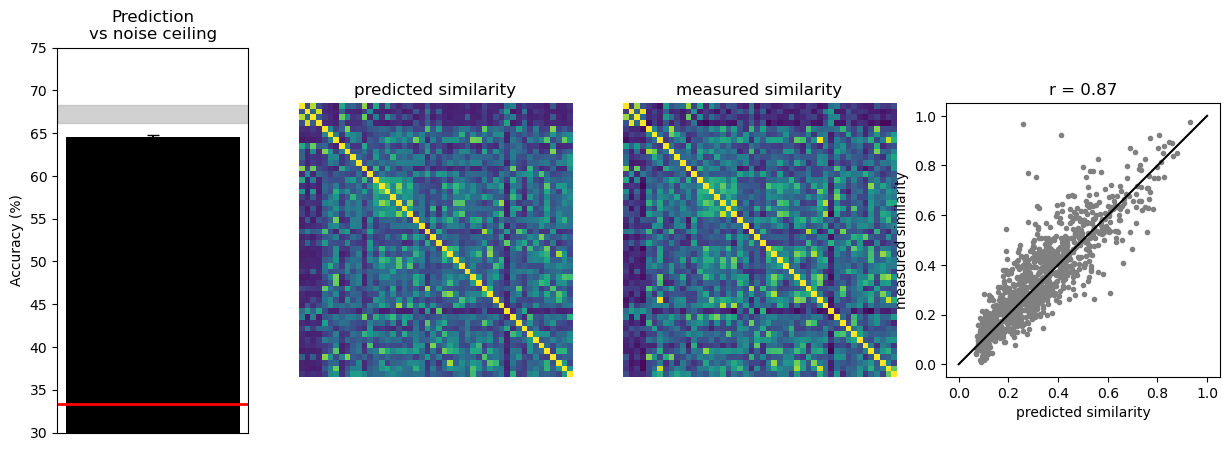

In [2]:
from things_spose.analysis import analyses, similarity, viz
pred = analyses.predict_triplets(ds.dot_product, ds.triplets_test, ds.n_objects)
ceil = analyses.noise_ceiling()
print(f'accuracy {pred.accuracy:.2f}%  ceiling {ceil.ceiling:.2f}%')
fig = viz.fig2_prediction(ds, pred=pred, ceiling=ceil, save_path='fig2.svg' if SAVE else None)
plt.show()